/tmp/ipython-input-1-2666548100.py:11: FutureWarning: YF.download() has changed argument auto_adjust default to True
  data = yf.download(symbol, start='2015-01-01', end='2024-12-31')
[*********************100%***********************]  1 of 1 completed


R² Score: 0.99989
Mean Squared Error: 0.46172


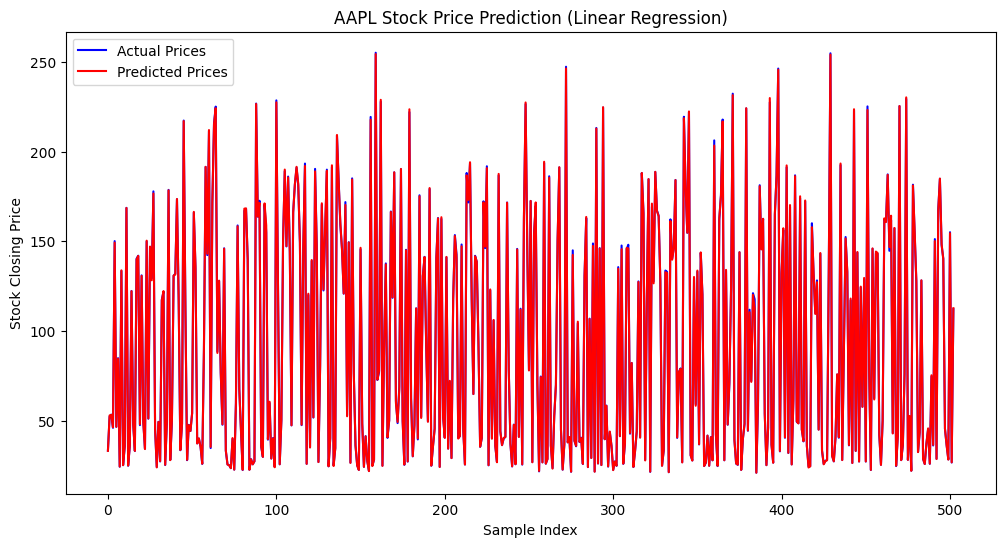

In [ ]:
import yfinance as yf
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import r2_score, mean_squared_error
import matplotlib.pyplot as plt

# 1. Download dataset
symbol = 'AAPL'  # Example: Apple Inc.
data = yf.download(symbol, start='2015-01-01', end='2024-12-31')

# 2. Select features and target
features = ['Open', 'High', 'Low', 'Volume']
target = 'Close'

X = data[features]
y = data[target]

# 3. Normalize features
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# 4. Split data
X_train, X_test, y_train, y_test = train_test_split(X_scaled, y, test_size=0.2, random_state=42)

# 5. Train Linear Regression model
model = LinearRegression()
model.fit(X_train, y_train)

# 6. Predict
y_pred = model.predict(X_test)

# 7. Evaluate
r2 = r2_score(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
print(f"R² Score: {r2:.5f}")
print(f"Mean Squared Error: {mse:.5f}")

# 8. Plot actual vs predicted prices
plt.figure(figsize=(12, 6))
plt.plot(y_test.values, label='Actual Prices', color='blue')
plt.plot(y_pred, label='Predicted Prices', color='red')
plt.title(f'{symbol} Stock Price Prediction (Linear Regression)')
plt.xlabel('Sample Index')
plt.ylabel('Stock Closing Price')
plt.legend()
plt.show()


/tmp/ipython-input-2-1068285094.py:11: FutureWarning: YF.download() has changed argument auto_adjust default to True
  data = yf.download(symbol, start='2015-01-01', end='2024-12-31')
[*********************100%***********************]  1 of 1 completed


R² Score: 0.99884


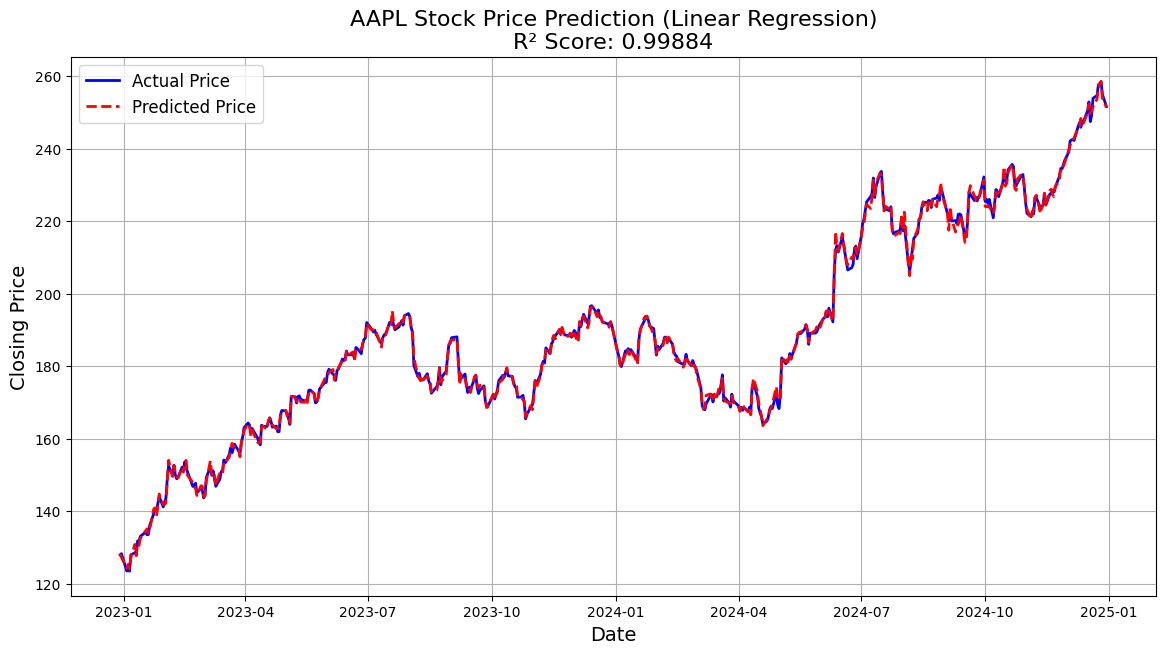

In [ ]:
import yfinance as yf
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import r2_score
import matplotlib.pyplot as plt

# 1. Download dataset
symbol = 'AAPL'  # Example: Apple Inc.
data = yf.download(symbol, start='2015-01-01', end='2024-12-31')

# 2. Select features and target
features = ['Open', 'High', 'Low', 'Volume']
target = 'Close'

X = data[features]
y = data[target]
dates = data.index  # Save dates for plotting

# 3. Normalize features
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# 4. Split data (keep date alignment for test set)
X_train, X_test, y_train, y_test, dates_train, dates_test = train_test_split(
    X_scaled, y, dates, test_size=0.2, shuffle=False
)

# 5. Train Linear Regression model
model = LinearRegression()
model.fit(X_train, y_train)

# 6. Predict
y_pred = model.predict(X_test)

# 7. Evaluate
r2 = r2_score(y_test, y_pred)
print(f"R² Score: {r2:.5f}")

# 8. Plot "Price vs Date"
plt.figure(figsize=(14, 7))
plt.plot(dates_test, y_test, label='Actual Price', color='blue', linewidth=2)
plt.plot(dates_test, y_pred, label='Predicted Price', color='red', linestyle='--', linewidth=2)
plt.title(f'{symbol} Stock Price Prediction (Linear Regression)\nR² Score: {r2:.5f}', fontsize=16)
plt.xlabel('Date', fontsize=14)
plt.ylabel('Closing Price', fontsize=14)
plt.legend(fontsize=12)
plt.grid(True)
plt.show()
